In [18]:
#r "C:\Users\Zver\Desktop\REPO\practice2026\practice2026\task17\bin\Debug\net9.0\task17.dll"
#r "nuget: SkiaSharp.NativeAssets.Linux.NoDependencies"
#r "nuget: ScottPlot, 5.0.21"

using System;
using System.Diagnostics;
using System.IO;
using System.Linq;
using System.Threading; 
using System.Collections.Generic;
using ScottPlot;
using task17; 
using Microsoft.DotNet.Interactive.Formatting;

Installed Packages ScottPlot, 5.0.21


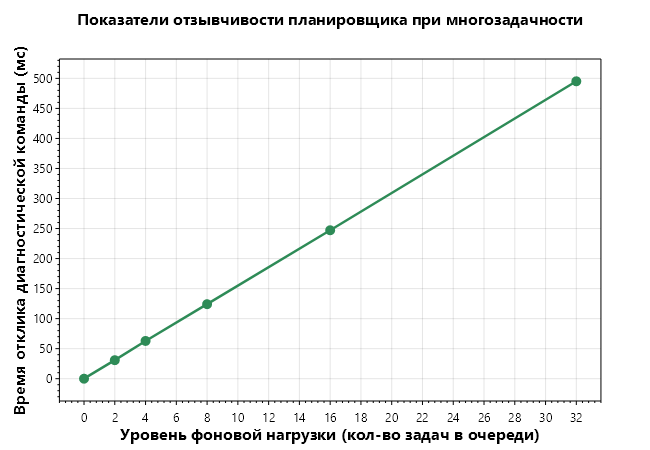

In [ ]:


Formatter.Register(typeof(Plot), (plotObj, writer) =>
{
    var plot = (Plot)plotObj;
    

    byte[] imageBytes = plot.GetImageBytes(650, 450, ImageFormat.Png);
    

    string base64String = Convert.ToBase64String(imageBytes);
    

    string html = $"<img src='data:image/png;base64,{base64String}' width='650' height='450' />";
    
    writer.Write(html);
}, HtmlFormatter.MimeType);

ScottPlot.Fonts.Default = "DejaVu Sans";


double EvaluateDelay(int backgroundTasksCount)
{
    var exceptionHandler = new ConsoleExceptionHandler(); // Нужно реализовать
    var server = new ServerThread(exceptionHandler);
    server.Start();
    

    for (int i = 0; i < backgroundTasksCount; i++)
    {
        server.QueueCommand(new SlicingTask(steps: 20));
    }

 
    var probe = new LatencyProbe();
    server.QueueCommand(probe);
    

    server.QueueCommand(new SoftStop(server)); 
    

    server.UnderlyingThread.Join();
    
    return probe.ElapsedMilliseconds;
}


const int RunCycles = 10;
int[] workloadPoints = { 0, 2, 4, 8, 16, 32 };
double[] latencyResults = new double[workloadPoints.Length];


for (int i = 0; i < workloadPoints.Length; i++)
{
    double[] runTimes = new double[RunCycles];
    for (int run = 0; run < RunCycles; run++)
    {
        runTimes[run] = EvaluateDelay(workloadPoints[i]);
    }
    latencyResults[i] = CalculateMedian(runTimes);
}


string reportPath = "result.txt";
using (var sw = new StreamWriter(reportPath))
{
    sw.WriteLine("Анализ отзывчивости распределителя задач");
    for (int i = 0; i < workloadPoints.Length; i++)
    {
        sw.WriteLine($"Активных фоновых задач: {workloadPoints[i]}  Время отклика: {latencyResults[i]:F3} ms");
    }
}


var plt = new ScottPlot.Plot();
double[] xs = workloadPoints.Select(n => (double)n).ToArray();
var scatter = plt.Add.Scatter(xs, latencyResults);

scatter.MarkerSize = 10;
scatter.LineWidth = 2.5f;
scatter.Color = new ScottPlot.Color(46, 139, 87);

plt.XLabel("Уровень фоновой нагрузки (кол-во задач в очереди)");
plt.YLabel("Время отклика диагностической команды (мс)");
plt.Title("Показатели отзывчивости планировщика при многозадачности");

plt.SavePng("plot.png", 800, 600);
plt.Display();


double CalculateMedian(double[] data)
{
    double[] temp = new double[data.Length];
    Array.Copy(data, temp, data.Length);
    Array.Sort(temp);
    
    int middle = temp.Length / 2;
    return (temp.Length % 2 != 0) 
        ? temp[middle] 
        : (temp[middle - 1] + temp[middle]) / 2.0;
}


public class LatencyProbe : ICommand
{
    private readonly Stopwatch _timer = Stopwatch.StartNew();
    public double ElapsedMilliseconds { get; private set; } = -1;

    public void Execute()
    {
        _timer.Stop();
        ElapsedMilliseconds = _timer.Elapsed.TotalMilliseconds;
    }
}

public class SlicingTask : ILongRunningCommand
{
    private readonly int _slicesCount;
    private int _completedSlices = 0;

    public SlicingTask(int steps) => _slicesCount = steps;

    public bool IsCompleted => _completedSlices >= _slicesCount;

    public void Execute()
    {
        if (!IsCompleted)
        {
            _completedSlices++;
            Thread.Sleep(1); 
        }
    }
}


public class ConsoleExceptionHandler : IExceptionHandler
{
    public void Handle(Exception exception, ICommand command)
    {
        Console.WriteLine($"Ошибка при выполнении команды {command.GetType().Name}: {exception.Message}");
        Console.WriteLine(exception.StackTrace);
    }
}
